In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Pour s'assurer que les graphiques s'affichent dans le notebook
%matplotlib inline

In [3]:
# Vu que le notebook est dans le dossier 'notebooks/', 
# on recule d'un dossier ('..') pour accéder à 'data/'
BASE_DIR = '..'
DATA_DIR = os.path.join(BASE_DIR, 'data')
RAW_DIR = os.path.join(DATA_DIR, 'raw')
IMG_DIR = os.path.join(DATA_DIR, 'images')

# Fichier des métadonnées (en supposant qu'il a l'extension .csv, 
# même si VS Code la masque parfois)
CSV_PATH = os.path.join(RAW_DIR, 'HAM10000_metadata')

print(f"Chemin du CSV : {CSV_PATH}")
print(f"Dossier des images : {IMG_DIR}")

Chemin du CSV : ..\data\raw\HAM10000_metadata
Dossier des images : ..\data\images


,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern


C:\Users\amine\AppData\Local\Temp\ipykernel_17508\3311504129.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='dx', order=df['dx'].value_counts().index, palette='viridis')


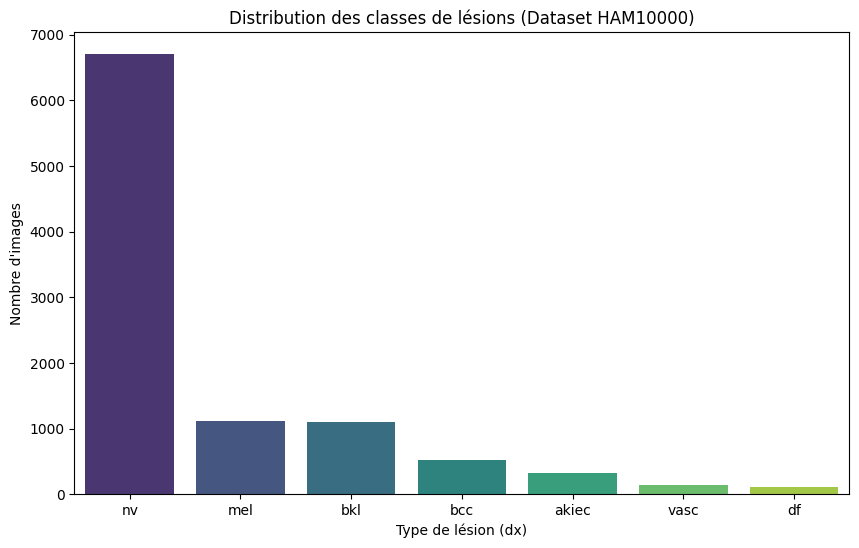


Répartition exacte :
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [4]:
# Chargement du dataframe
df = pd.read_csv(CSV_PATH)

# Affichage des 5 premières lignes pour vérifier
display(df.head())

# Visualisation du déséquilibre des classes
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='dx', order=df['dx'].value_counts().index, palette='viridis')
plt.title('Distribution des classes de lésions (Dataset HAM10000)')
plt.xlabel('Type de lésion (dx)')
plt.ylabel("Nombre d'images")
plt.show()

print("\nRépartition exacte :")
print(df['dx'].value_counts())

In [7]:
# 1. Création d'un dictionnaire pour convertir les classes (texte) en nombres (0 à 6)
classes = df['dx'].unique()
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

print(f"Mapping des classes : {class_to_idx}")

# Application du mapping pour créer une nouvelle colonne 'label'
df['label'] = df['dx'].map(class_to_idx)

# 2. Ajout du chemin complet pour chaque image (.jpg)
# Cela facilitera le chargement par PyTorch
df['image_path'] = df['image_id'].apply(lambda x: os.path.join(IMG_DIR, f"{x}.jpg"))

Mapping des classes : {'bkl': 0, 'nv': 1, 'df': 2, 'mel': 3, 'vasc': 4, 'bcc': 5, 'akiec': 6}


In [8]:
class HAM10000Dataset(Dataset):
    """Dataset personnalisé pour lire les images et les labels."""
    
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # Récupération du chemin de l'image et du label
        img_path = self.dataframe.iloc[idx]['image_path']
        label = self.dataframe.iloc[idx]['label']
        
        # Chargement de l'image avec PIL (format attendu par PyTorch)
        try:
            image = Image.open(img_path).convert('RGB')
        except FileNotFoundError:
            # Sécurité au cas où une image manque dans ton dossier
            print(f"Erreur : Image introuvable à {img_path}")
            # On retourne une image noire par défaut pour ne pas crasher
            image = Image.new('RGB', (224, 224)) 

        # Application de la Data Augmentation / Prétraitement
        if self.transform:
            image = self.transform(image)

        # On s'assure que le label est un tenseur de type long (entier)
        return image, torch.tensor(label, dtype=torch.long)

In [9]:
# Standard ImageNet (moyennes et écarts-types)
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

# Pipeline d'entraînement (AVEC augmentation pour éviter le surapprentissage)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),            # Redimensionnement standard
    transforms.RandomHorizontalFlip(p=0.5),   # Miroir horizontal
    transforms.RandomVerticalFlip(p=0.5),     # Miroir vertical
    transforms.RandomRotation(degrees=20),    # Rotation de ±20 degrés
    transforms.ToTensor(),                    # Conversion en Tenseur PyTorch
    normalize                                 # Normalisation
])

# Pipeline de validation/test (SANS augmentation, juste le formatage)
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    normalize
])

In [10]:
# Création d'une instance de notre dataset (sur tout le dataframe pour tester)
test_dataset = HAM10000Dataset(dataframe=df, transform=train_transforms)

# Création du DataLoader (qui enverra les images par batch)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

# Récupération d'un seul batch pour vérifier que tout fonctionne
images, labels = next(iter(test_loader))

print(f"Forme du tenseur d'images : {images.shape} -> (Batch, Canaux, Hauteur, Largeur)")
print(f"Forme du tenseur de labels : {labels.shape}")
print("Si ces dimensions s'affichent, ton pipeline de données est opérationnel ! ✅")

Forme du tenseur d'images : torch.Size([32, 3, 224, 224]) -> (Batch, Canaux, Hauteur, Largeur)
Forme du tenseur de labels : torch.Size([32])
Si ces dimensions s'affichent, ton pipeline de données est opérationnel ! ✅
